# Математическая статистика для анализа больших данных.
## Задание 8
### MDE

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps
from tqdm import tqdm

---
### Задача 1 (2 балла)

Выведите формулу MDE для относительного t-теста.

Минимально детектируемый эффект (MDE) — это минимальный размер эффекта, который может быть обнаружен с заданной мощностью $\beta$ и уровнем значимости $\alpha$. Для относительного t-теста, где статистика критерия основана на относительной разнице между средними двух выборок, формула MDE может быть выведена следующим образом.

В относительном t-тесте статистика относительной разницы определяется как:

$$
R = \frac{\bar{X} - \bar{Y}}{\bar{Y}},
$$

где $\bar{X}$ и $\bar{Y}$ — выборочные средние двух независимых выборок объёмов $n$ и $m$ соответственно.


Чтобы найти MDE, необходимо определить стандартную ошибку $SE_R$ статистики $R$. Используя метод дельта, приближённо вычислим дисперсию $R$.

Частные производные $R$ по $\bar{X}$ и $\bar{Y}$:

$$
\frac{\partial R}{\partial \bar{X}} = \frac{1}{\bar{Y}}, \quad \frac{\partial R}{\partial \bar{Y}} = -\frac{\bar{X} - \bar{Y}}{\bar{Y}^2}.
$$

При нулевой гипотезе $H_0: \bar{X} = \bar{Y} = \mu$ имеем $\bar{X} - \bar{Y} = 0$, поэтому:

$$
\frac{\partial R}{\partial \bar{Y}} = -\frac{1}{\bar{Y}}.
$$

Дисперсия $R$:

$$
\text{Var}(R) \approx \left(\frac{\partial R}{\partial \bar{X}}\right)^2 \text{Var}(\bar{X}) + \left(\frac{\partial R}{\partial \bar{Y}}\right)^2 \text{Var}(\bar{Y}).
$$

Подставим частные производные и дисперсии выборочных средних:

$$
\text{Var}(\bar{X}) = \frac{\sigma_X^2}{n}, \quad \text{Var}(\bar{Y}) = \frac{\sigma_Y^2}{m}.
$$

Тогда:

$$
\text{Var}(R) \approx \left(\frac{1}{\mu}\right)^2 \left(\frac{\sigma_X^2}{n} + \frac{\sigma_Y^2}{m}\right).
$$

Стандартная ошибка $SE_R$:

$$
SE_R = \sqrt{\text{Var}(R)} = \frac{\sqrt{\frac{\sigma_X^2}{n} + \frac{\sigma_Y^2}{m}}}{\mu}.
$$

При заданных уровне значимости $\alpha$ и мощности $\beta$, критические значения нормального распределения:

- $z_{1-\alpha/2}$ — квантиль для уровня значимости $\alpha$ (двусторонний тест).
- $z_{1-\beta}$ — квантиль, соответствующий мощности $\beta$.

Минимально детектируемый эффект $\delta$ тогда выражается как:

$$
\delta = MDE = (z_{1-\alpha/2} + z_{1-\beta}) \cdot SE_R.
$$

Подставляя выражение для $SE_R$:

$$
MDE = (z_{1-\alpha/2} + z_{1-\beta}) \cdot \frac{\sqrt{\frac{\sigma_X^2}{n} + \frac{\sigma_Y^2}{m}}}{\mu}.
$$


Если предположить, что дисперсии выборок равны ($\sigma_X^2 = \sigma_Y^2 = \sigma^2$) и объёмы выборок одинаковы ($n = m$), формула упрощается:

$$
MDE = (z_{1-\alpha/2} + z_{1-\beta}) \cdot \frac{\sigma}{\mu \sqrt{n}}.
$$

Таким образом, формула для минимально детектируемого эффекта (MDE) в относительном t-тесте имеет вид:

$$
MDE = (z_{1-\alpha/2} + z_{1-\beta}) \cdot \frac{\sqrt{\frac{\sigma_X^2}{n} + \frac{\sigma_Y^2}{m}}}{\mu},
$$



---
### Задача 2 (10 баллов)
В одной компании собираются проводить эксперимент о принятии новой фичи продукта. Перед командой аналитики стоит задача о корректном проведении AB-тестирования. У вас имеются исторические данные по пользователям за некоторый период. С помощью них проведите дизайн эксперимента.

1. Для начала нужно определить **целевую переменную**. На самом деле зависит от целевой метрики продукта и от характера внедряемой фичи. Мы будем использовать среднюю прибыль с одного пользователя как таргет, который необходимо увеличивать.



Проведем небольшой разведывательный анализ. Посмотрим на количество уникальных пользователей, общую прибыль за весь период, среднюю прибыль за месяц и другие метрики, на которые вы захотите посмотреть.

In [7]:
df = pd.read_csv('hw_task2.csv')
print(df.head())


  user_id        date   spent
0    id_0  30-10-2022  182.56
1    id_0  09-10-2022   84.54
2    id_0  20-10-2022   96.02
3    id_0  05-09-2022   51.52
4    id_0  29-05-2022  126.36


In [10]:
# Оставляем только строки, где 'date' соответствует формату даты
df = df[df['date'].str.match(r'\d{2}-\d{2}-\d{4}')]

# Сбрасываем индексы после удаления строк
df.reset_index(drop=True, inplace=True)



In [11]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)


In [12]:
num_users = df['user_id'].nunique()
print(f"Количество уникальных пользователей: {num_users}")

Количество уникальных пользователей: 28364


In [13]:
total_profit = df['spent'].sum()
print(f"Общая прибыль за весь период: {total_profit:.2f}")


Общая прибыль за весь период: 1145461724.78


In [15]:
df['month'] = df['date'].dt.to_period('M')
monthly_profit = df.groupby('month')['spent'].sum()
average_monthly_profit = monthly_profit.mean()
print(f"Средняя ежемесячная прибыль: {average_monthly_profit:.2f}")

Средняя ежемесячная прибыль: 95455143.73


Не забываем про визуализацию

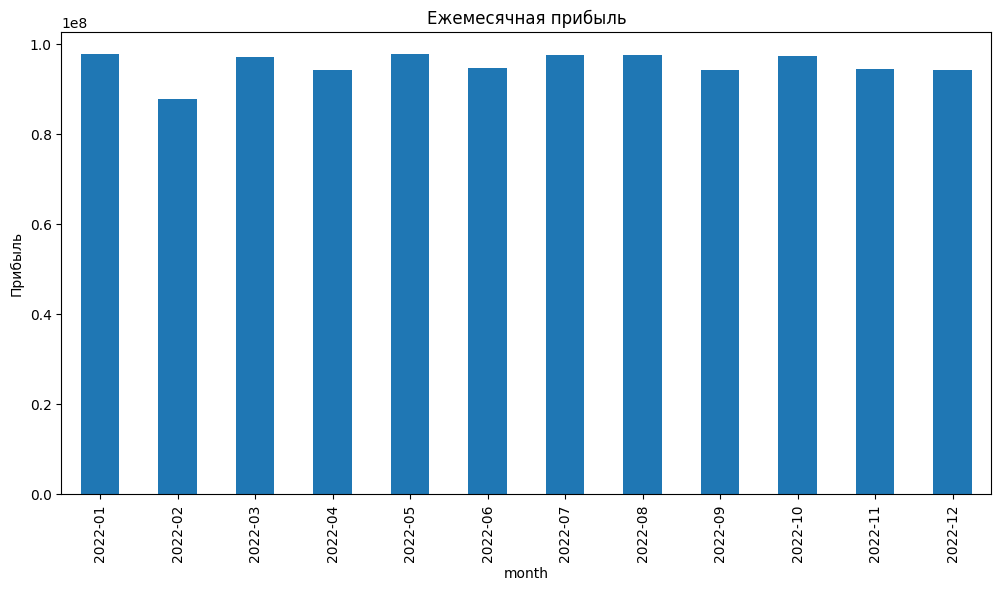

In [17]:
plt.figure(figsize=(12,6))
monthly_profit.plot(kind='bar')
plt.ylabel('Прибыль')
plt.title('Ежемесячная прибыль')
plt.show()


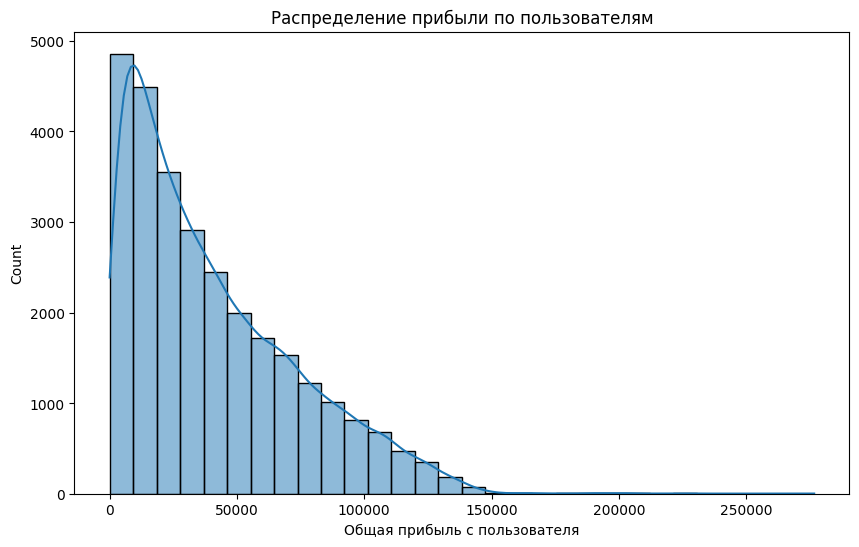

In [18]:
user_total_spent = df.groupby('user_id')['spent'].sum()
plt.figure(figsize=(10,6))
sns.histplot(user_total_spent, bins=30, kde=True)
plt.xlabel('Общая прибыль с пользователя')
plt.title('Распределение прибыли по пользователям')
plt.show()


На первом графике показана ежемесячная прибыль за 2022 год. Прибыль относительно стабильна в каждом месяце, что указывает на отсутствие выраженной сезонности или значительных колебаний в доходах компании. Это является хорошим индикатором для проведения A/B-тестирования, так как позволяет избежать сезонных и временных факторов, влияющих на прибыль.

На втором графике представлено распределение прибыли по пользователям. Видно, что большинство пользователей приносят относительно низкий доход, в то время как меньшинство генерирует высокую прибыль. Такое распределение, где прибыль концентрируется у небольшого числа пользователей, свидетельствует о правостороннем распределении (с длинным хвостом). Это может повлиять на дизайн эксперимента, так как результаты A/B-теста могут сильно зависеть от доходов отдельных крупных пользователей.

2. **Максимально возможная длительность AB-эксперимента**.  
* Не имеет смысла держать эксперимент слишком мало, так как может не набраться нужная выборка, а также выше влияние шумов, вызванных интервалом времени, в котором проводится эксперимент.


* Аналогично, не имеет смысл держать эксперимент слишком долго, ведь существуют продуктовые риски, а также терпение заказчика.


Есть некоторые здравые правила, на которые можно опираться. Например, при анализе пользователей стоит выбирать длительность, кратную семи дням, для учета сезонной периодичности.

Опираясь на данные зафиксируйте продолжительность эксперимента

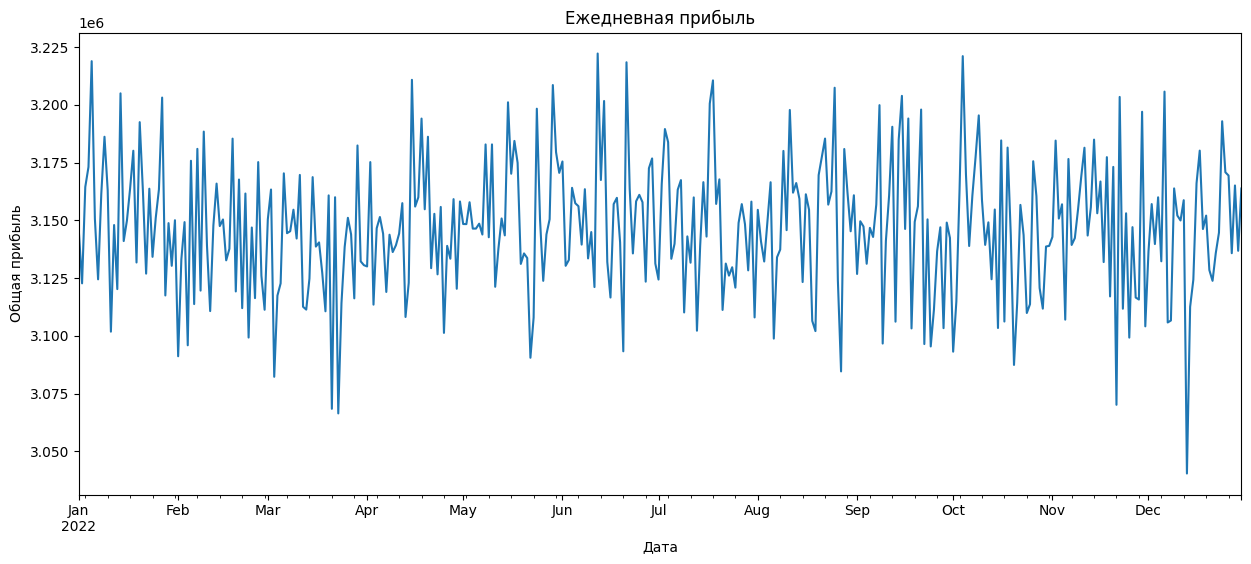

In [20]:
# Рассчитываем общую прибыль по дням
daily_revenue = df.groupby('date')['spent'].sum()

# Построение графика ежедневной прибыли
plt.figure(figsize=(15,6))
daily_revenue.plot()
plt.xlabel('Дата')
plt.ylabel('Общая прибыль')
plt.title('Ежедневная прибыль')
plt.show()


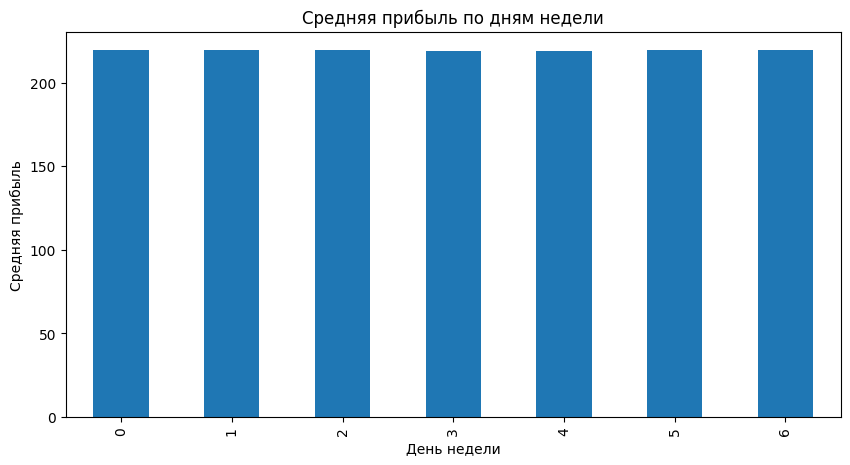

In [21]:
# Добавляем столбец с днем недели (0 - понедельник, 6 - воскресенье)
df['weekday'] = df['date'].dt.dayofweek

# Рассчитываем среднюю прибыль по дням недели
weekday_revenue = df.groupby('weekday')['spent'].mean()

# Визуализация средней прибыли по дням недели
plt.figure(figsize=(10,5))
weekday_revenue.plot(kind='bar')
plt.xlabel('День недели')
plt.ylabel('Средняя прибыль')
plt.title('Средняя прибыль по дням недели')
plt.show()


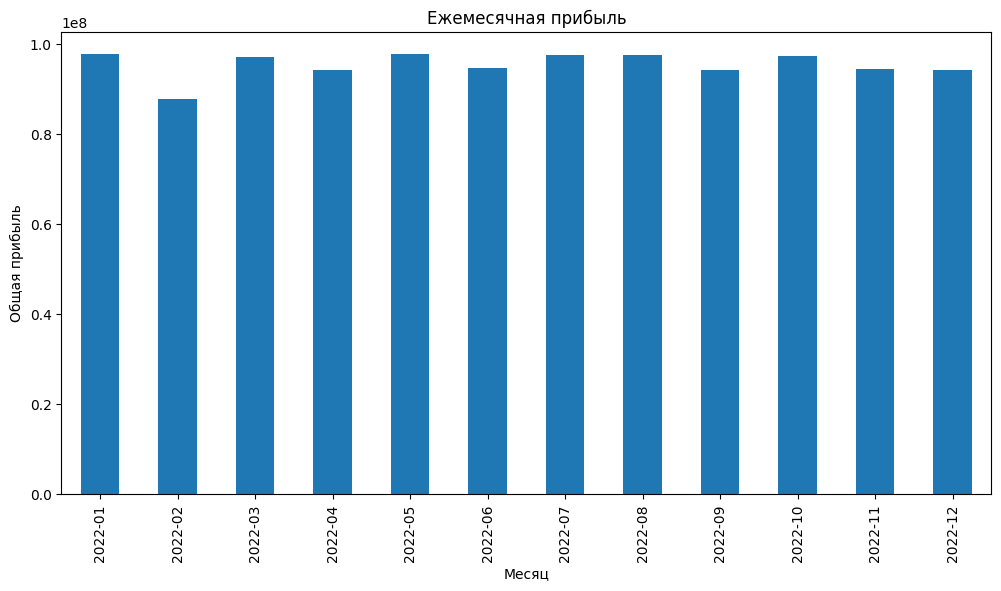

In [22]:
# Рассчитываем общую прибыль по месяцам
monthly_revenue = df.groupby(df['date'].dt.to_period('M'))['spent'].sum()

# Визуализация ежемесячной прибыли
plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='bar')
plt.xlabel('Месяц')
plt.ylabel('Общая прибыль')
plt.title('Ежемесячная прибыль')
plt.show()


На первом графике показана ежедневная прибыль за 2022 год. Видно, что прибыль колеблется, но остается в определенном диапазоне, без значительных выбросов или сильных тенденций роста/спада. Это указывает на устойчивость ежедневной прибыли, что позволяет оценивать стабильность тестирования при запуске AB-эксперимента.

На втором графике представлена средняя прибыль по дням недели. Значительных различий между днями недели не наблюдается — прибыль остается примерно на одном уровне. Это позволяет предположить, что сезонность в пределах недели незначительна, и нет выраженных пиков или спадов в определенные дни.

На третьем графике показана ежемесячная прибыль. В течение года прибыль достаточно стабильна, с небольшими колебаниями. Исходя из этого, можно выбрать длительность AB-эксперимента, кратную семи дням (например, 4 недели или 8 недель), для учета сезонности, не опасаясь значительных отклонений, связанных с временными факторами.

Вывод по длительности эксперимента:
Оптимальная длительность эксперимента составляет 4-8 недель. Это даст возможность собрать достаточное количество данных для анализа, избежать влияния случайных шумов и снизить риски сезонных колебаний.

3. **Размеры A и B групп.**

Их оценим исходя из возможных рисков. Пусть в тестовой группе $n$ человек. Предположим, что эксперимент может быть ухудшающим, и мы потеряем доход со всех пользователей тестовой группы. Допустим, мы выбрали длительность эксперимента в $T$ дней и оценили, что каждый пользователь в среднем в день тратит примерно в $x$ единиц.

Тогда потери с тестовой группы за все время эксперимента составит $T \cdot n \cdot x$. Пусть не хотим, чтоб это значение превышало $1\%$ возможного дохода за период T (пусть он будет равен N). В таком случае получаем

$$T \cdot n \cdot x \leq N \cdot 0.01$$

Исходя из этого оцените n:


Средняя ежедневная прибыль с пользователя: 300.32


4. **Статистический критерий**.

Будем использовать относительный двусторонний t-test для независимых выборок с уровнем значимости $\alpha=0.05$.


T-test довольно хорошо справляется с выборками из большинства распределений, а также имеет понятную для заказчика статистику. Двусторонний вариант выбран для того, чтобы отловить отрицательные изменения и разобраться в них.

5. **Желаемый минимальный детектируемый эффект и мощность критерия.**

Будем подбирать по рассмотренной на семинаре таблице MDE-мощность-размер выборки. Так как критерий двусторонний, $\alpha$ в формулах заменяется на $\alpha/2$. $n$ вы оценили ранее.

In [ ]:
<...>

Но перед этим необходимо оценить дисперсию выборок. Для этого будет семплировать пользователей и рассматривать периоды в $T$ дней. Затем саггрегируем данные по пользователям, расчитаем оценку дисперсии и посмотрим, как менялась дисперсия исторических данных со временем. А в качестве оценки возьмем среднее дисперсий за все периоды. После этого мы сможем, расчитать таблицу с MDE

In [ ]:
<...>

Выберете желаемую мощность и размер выборки

6. Для выбранного критерия проведите АА-тест по историческим данным, семплируя момент времени начала эксперимента и сами группы пользователей. Следите чтобы используемые интервалы времени не выходили за границы доступных данных.

In [ ]:
<...>

Не забывайте про выводы после каждого этапа. А также про общий вывод по всей задаче